In [2]:
import pandas as pd

df = pd.read_csv("../Data/Jobs.csv")

df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,MI,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,SE,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,SE,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,MI,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,SE,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Unnamed: 0          607 non-null    int64
 1   work_year           607 non-null    int64
 2   experience_level    607 non-null    str  
 3   employment_type     607 non-null    str  
 4   job_title           607 non-null    str  
 5   salary              607 non-null    int64
 6   salary_currency     607 non-null    str  
 7   salary_in_usd       607 non-null    int64
 8   employee_residence  607 non-null    str  
 9   remote_ratio        607 non-null    int64
 10  company_location    607 non-null    str  
 11  company_size        607 non-null    str  
dtypes: int64(5), str(7)
memory usage: 57.0 KB


In [4]:
df.describe()

,Unnamed: 0,work_year,salary,salary_in_usd,remote_ratio
count,607.000000,607.000000,6.070000e+02,607.000000,607.00000
mean,303.000000,2021.405272,3.240001e+05,112297.869852,70.92257
std,175.370085,0.692133,1.544357e+06,70957.259411,40.70913
min,0.000000,2020.000000,4.000000e+03,2859.000000,0.00000
25%,151.500000,2021.000000,7.000000e+04,62726.000000,50.00000
50%,303.000000,2022.000000,1.150000e+05,101570.000000,100.00000
75%,454.500000,2022.000000,1.650000e+05,150000.000000,100.00000
max,606.000000,2022.000000,3.040000e+07,600000.000000,100.00000


In [5]:
df.isnull().sum()

Unnamed: 0            0
work_year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [6]:
top_paying = df.groupby("job_title")["salary_in_usd"].mean().sort_values(ascending=False)

top_paying.head(10)

job_title
Data Analytics Lead         405000.000000
Principal Data Engineer     328333.333333
Financial Data Analyst      275000.000000
Principal Data Scientist    215242.428571
Director of Data Science    195074.000000
Data Architect              177873.909091
Applied Data Scientist      175655.000000
Analytics Engineer          175000.000000
Data Specialist             165000.000000
Head of Data                160162.600000
Name: salary_in_usd, dtype: float64

In [7]:
salary_by_exp = df.groupby("experience_level")["salary_in_usd"].mean()

salary_by_exp

experience_level
EN     61643.318182
EX    199392.038462
MI     87996.056338
SE    138617.292857
Name: salary_in_usd, dtype: float64

In [8]:
df["company_location"].value_counts().head(10)

company_location
US    355
GB     47
CA     30
DE     28
IN     24
FR     15
ES     14
GR     11
JP      6
NL      4
Name: count, dtype: int64

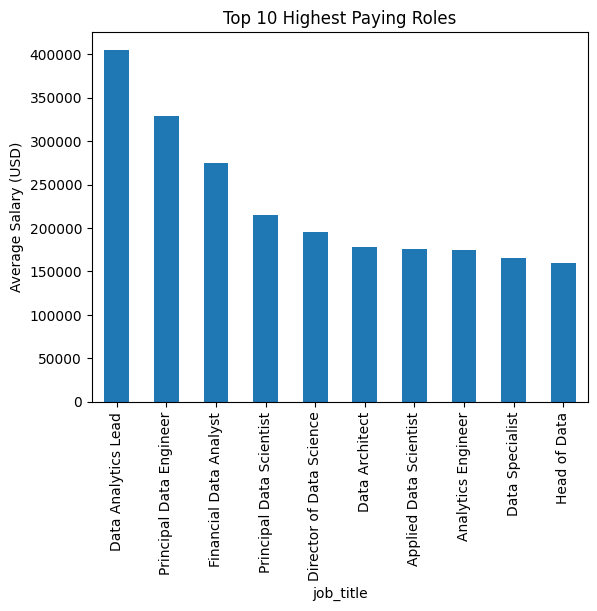

In [11]:
import matplotlib.pyplot as plt

top_paying.head(10).plot(kind="bar")
plt.title("Top 10 Highest Paying Roles")
plt.ylabel("Average Salary (USD)")
plt.show()

In [12]:
df["experience_level"].unique()

<StringArray>
['MI', 'SE', 'EN', 'EX']
Length: 4, dtype: str

In [13]:
exp_map = {
    "EN": "Entry Level",
    "MI": "Mid Level",
    "SE": "Senior Level",
    "EX": "Executive"
}

df["experience_level"] = df["experience_level"].map(exp_map)

df.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,Mid Level,FT,Data Scientist,70000,EUR,79833,DE,0,DE,L
1,1,2020,Senior Level,FT,Machine Learning Scientist,260000,USD,260000,JP,0,JP,S
2,2,2020,Senior Level,FT,Big Data Engineer,85000,GBP,109024,GB,50,GB,M
3,3,2020,Mid Level,FT,Product Data Analyst,20000,USD,20000,HN,0,HN,S
4,4,2020,Senior Level,FT,Machine Learning Engineer,150000,USD,150000,US,50,US,L


In [14]:
remote_jobs = df.groupby("remote_ratio")["salary_in_usd"].mean()

remote_jobs

remote_ratio
0      106354.622047
50      80823.030303
100    122457.454068
Name: salary_in_usd, dtype: float64

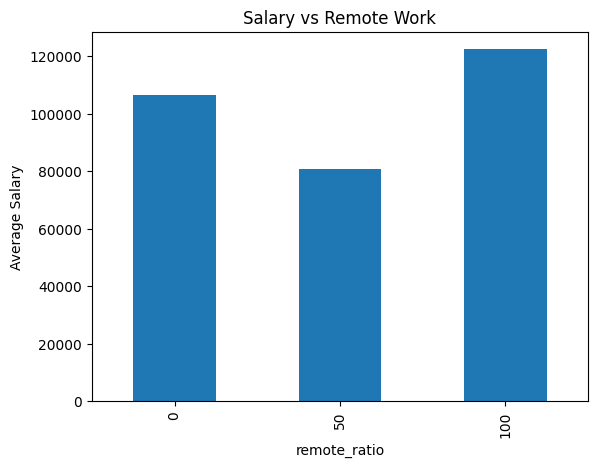

In [15]:
remote_jobs.plot(kind="bar")
plt.title("Salary vs Remote Work")
plt.ylabel("Average Salary")
plt.show()

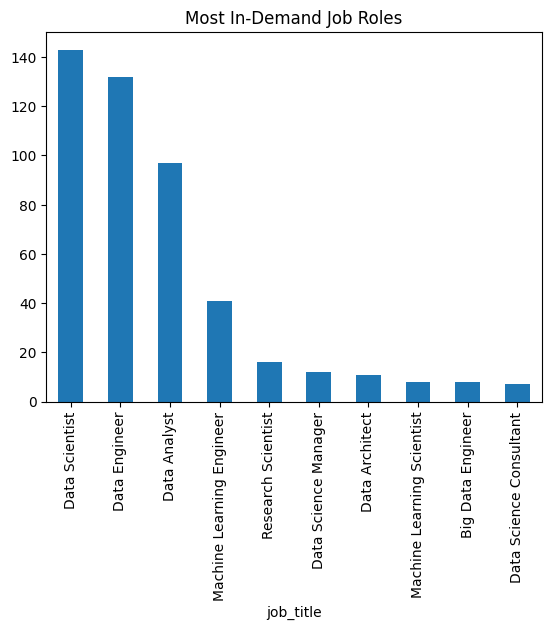

In [16]:
top_roles = df["job_title"].value_counts().head(10)

top_roles.plot(kind="bar")
plt.title("Most In-Demand Job Roles")
plt.show()

In [18]:
import sys
!{sys.executable} -m pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 7.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 7.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


In [19]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [20]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_ml = df.copy()

df_ml["job_title"] = le.fit_transform(df_ml["job_title"])
df_ml["experience_level"] = le.fit_transform(df_ml["experience_level"])
df_ml["employment_type"] = le.fit_transform(df_ml["employment_type"])
df_ml["company_location"] = le.fit_transform(df_ml["company_location"])

df_ml.head()

,Unnamed: 0,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,0,2020,2,2,22,70000,EUR,79833,DE,0,12,L
1,1,2020,3,2,41,260000,USD,260000,JP,0,29,S
2,2,2020,3,2,7,85000,GBP,109024,GB,50,18,M
3,3,2020,2,2,47,20000,USD,20000,HN,0,20,S
4,4,2020,3,2,38,150000,USD,150000,US,50,48,L


In [21]:
X = df_ml.drop("salary_in_usd", axis=1)
y = df_ml["salary_in_usd"]

print(X.shape)
print(y.shape)

(607, 11)
(607,)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [24]:
df_ml.dtypes

Unnamed: 0            int64
work_year             int64
experience_level      int64
employment_type       int64
job_title             int64
salary                int64
salary_currency         str
salary_in_usd         int64
employee_residence      str
remote_ratio          int64
company_location      int64
company_size            str
dtype: object

In [25]:
df_ml = df[[
    "experience_level",
    "employment_type",
    "company_location",
    "remote_ratio",
    "salary_in_usd"
]].copy()

# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_ml["experience_level"] = le.fit_transform(df_ml["experience_level"])
df_ml["employment_type"] = le.fit_transform(df_ml["employment_type"])
df_ml["company_location"] = le.fit_transform(df_ml["company_location"])

df_ml.head()

,experience_level,employment_type,company_location,remote_ratio,salary_in_usd
0,2,2,12,0,79833
1,3,2,29,0,260000
2,3,2,18,50,109024
3,2,2,20,0,20000
4,3,2,48,50,150000


In [26]:
df_ml.dtypes

experience_level    int64
employment_type     int64
company_location    int64
remote_ratio        int64
salary_in_usd       int64
dtype: object

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df_ml.drop("salary_in_usd", axis=1)
y = df_ml["salary_in_usd"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model Trained Successfully ✅")

Model Trained Successfully ✅


In [28]:
predictions = model.predict(X_test)

score = r2_score(y_test, predictions)

print("Model Accuracy:", score)

Model Accuracy: 0.2670194685252174


In [29]:
from sklearn.ensemble import RandomForestRegressor

In [30]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained ✅")

Random Forest Model Trained ✅


In [31]:
rf_predictions = rf_model.predict(X_test)

In [32]:
rf_score = r2_score(y_test, rf_predictions)

print("Random Forest Accuracy:", rf_score)

Random Forest Accuracy: 0.39206218126682824


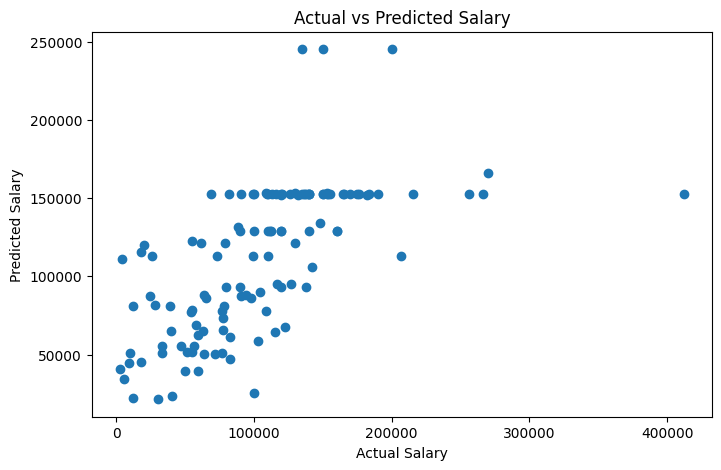

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, rf_predictions)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

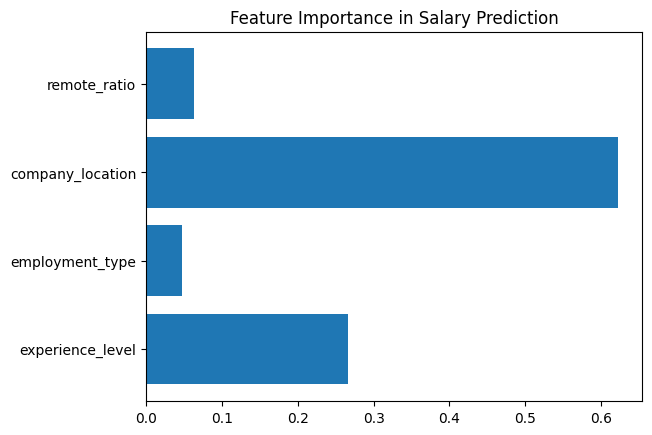

In [34]:
importance = rf_model.feature_importances_

features = X.columns

plt.barh(features, importance)
plt.title("Feature Importance in Salary Prediction")
plt.show()

In [36]:
df.to_csv("../dashboards/job_market_dashboard.csv", index=False)